In [1]:
import numpy
print("NumPy:", numpy.__version__)

import scipy
print("SciPy:", scipy.__version__)

import sklearn
print("Scikit-learn:", sklearn.__version__)

import transformers
print("Transformers:", transformers.__version__)

NumPy: 1.26.4
SciPy: 1.16.3
Scikit-learn: 1.6.1
Transformers: 5.0.0


In [2]:
# ============================================================
# CELL 1 : Environment Setup
# ============================================================

import os
import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("Device :", DEVICE)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print(
        "GPU Memory : {:.2f} GB".format(
            torch.cuda.get_device_properties(0).total_memory / 1024**3
        )
    )

print("=" * 60)

# ------------------------------------------------------------
# Project Directories
# ------------------------------------------------------------
PROJECT_DIR = Path("/kaggle/working")

CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
RESULT_DIR = PROJECT_DIR / "results"
LOG_DIR = PROJECT_DIR / "logs"
PLOT_DIR = PROJECT_DIR / "plots"

CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

print("Project Directory :", PROJECT_DIR)
print("Checkpoint Dir    :", CHECKPOINT_DIR)
print("Result Dir        :", RESULT_DIR)
print("Log Dir           :", LOG_DIR)
print("Plot Dir          :", PLOT_DIR)

print("=" * 60)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Environment Ready.")

Device : cuda
GPU : Tesla T4
GPU Memory : 14.56 GB
Project Directory : /kaggle/working
Checkpoint Dir    : /kaggle/working/checkpoints
Result Dir        : /kaggle/working/results
Log Dir           : /kaggle/working/logs
Plot Dir          : /kaggle/working/plots
Environment Ready.


In [3]:
!git clone https://github.com/Mohmed-Husain/PPFLCTRURH.git

fatal: destination path 'PPFLCTRURH' already exists and is not an empty directory.


In [4]:
!ls PPFLCTRURH

 AAAI_Four_Papers_Concepts.docx  'NLP pipline'
 dataset_transformed.jsonl	 'Project Overview.md'
 FEDERATED_HANDOFF.md		 'Project Working Pipline.md'
'Federated pipline'


In [5]:
!ls "PPFLCTRURH/NLP pipline/federated_handoff"

nlp_pipeline  README.md  setup.py


In [6]:
# ============================================================
# CELL 4 : Add NLP Package to Python Path
# ============================================================

import os
import sys

PROJECT_PATH = "/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff"

if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

print("Project Path Added Successfully.")
print(PROJECT_PATH)

print("\nFiles inside project:\n")
print(os.listdir(PROJECT_PATH))

Project Path Added Successfully.
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff

Files inside project:

['nlp_pipeline', 'setup.py', 'README.md']


In [7]:
# ============================================================
# CELL 5 : Test Basic Import
# ============================================================

from nlp_pipeline.configs.config import PipelineConfig

print("✅ PipelineConfig Imported Successfully")
print(PipelineConfig)

✅ PipelineConfig Imported Successfully
<class 'nlp_pipeline.configs.config.PipelineConfig'>


In [8]:
# ============================================================
# CELL 6 : Verify Required Project Files
# ============================================================

import os

ROOT = "/kaggle/working/PPFLCTRURH"

files = [
    "dataset_transformed.jsonl",
    "label_encoder.json",
    "label_hierarchy.json"
]

print("="*60)

for f in files:
    path = os.path.join(ROOT, f)
    print(f"{f:30}", os.path.exists(path))

print("="*60)

dataset_transformed.jsonl      True
label_encoder.json             False
label_hierarchy.json           False


In [9]:
# ============================================================
# CELL 6A : Find Required Files
# ============================================================

import os

ROOT = "/kaggle/working/PPFLCTRURH"

for root, dirs, files in os.walk(ROOT):
    for file in files:
        if file in [
            "label_encoder.json",
            "label_hierarchy.json",
            "dataset_transformed.jsonl"
        ]:
            print(os.path.join(root, file))

/kaggle/working/PPFLCTRURH/dataset_transformed.jsonl
/kaggle/working/PPFLCTRURH/NLP pipline/training_outputs/label_encoder.json
/kaggle/working/PPFLCTRURH/NLP pipline/training_outputs/label_hierarchy.json


In [10]:
# ============================================================
# CELL 7 : Define Project Paths
# ============================================================

from pathlib import Path

# Repository Root
ROOT_DIR = Path("/kaggle/working/PPFLCTRURH")

# NLP Pipeline
NLP_DIR = ROOT_DIR / "NLP pipline"

# Federated Handoff Package
HANDOFF_DIR = NLP_DIR / "federated_handoff"

# Training Outputs
TRAINING_OUTPUTS = NLP_DIR / "training_outputs"

# Dataset
DATASET_PATH = ROOT_DIR / "dataset_transformed.jsonl"

# Label Files
LABEL_ENCODER_PATH = TRAINING_OUTPUTS / "label_encoder.json"
LABEL_HIERARCHY_PATH = TRAINING_OUTPUTS / "label_hierarchy.json"

print("=" * 60)
print("ROOT_DIR              :", ROOT_DIR)
print("DATASET_PATH          :", DATASET_PATH)
print("LABEL_ENCODER_PATH    :", LABEL_ENCODER_PATH)
print("LABEL_HIERARCHY_PATH  :", LABEL_HIERARCHY_PATH)
print("=" * 60)

ROOT_DIR              : /kaggle/working/PPFLCTRURH
DATASET_PATH          : /kaggle/working/PPFLCTRURH/dataset_transformed.jsonl
LABEL_ENCODER_PATH    : /kaggle/working/PPFLCTRURH/NLP pipline/training_outputs/label_encoder.json
LABEL_HIERARCHY_PATH  : /kaggle/working/PPFLCTRURH/NLP pipline/training_outputs/label_hierarchy.json


In [11]:
# ============================================================
# CELL 8 : Verify Project Files
# ============================================================

files = {
    "Dataset": DATASET_PATH,
    "Label Encoder": LABEL_ENCODER_PATH,
    "Label Hierarchy": LABEL_HIERARCHY_PATH,
}

print("=" * 60)

for name, path in files.items():
    print(f"{name:20} : {'✅ Found' if path.exists() else '❌ Missing'}")

print("=" * 60)

Dataset              : ✅ Found
Label Encoder        : ✅ Found
Label Hierarchy      : ✅ Found


In [12]:
# ============================================================
# CELL 9 : Load Dataset
# ============================================================

import json
import pandas as pd

records = []

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)

print("="*60)
print("Dataset Loaded Successfully")
print("Number of Records :", len(df))
print("Number of Columns :", len(df.columns))
print("="*60)

Dataset Loaded Successfully
Number of Records : 745
Number of Columns : 12


In [13]:
# ============================================================
# CELL 10 : Inspect Dataset
# ============================================================

print("Columns:\n")
print(df.columns.tolist())

print("\n")

print(df.head())

print("\n")

print(df.info())

Columns:

['doc_id', 'text', 'parent_labels', 'child_labels', 'parent_label_ids', 'child_label_ids', 'icd_codes', 'source', 'llm_confidence', 'site_id', 'split', 'text_length']


             doc_id                                               text  \
0  dc3cc7e4c0756745  Alzheimer's Research Assistant - Corpus Invent...   
1  d4c69bf3546f31c0  Biofluid biomarker data This section provides ...   
2  23e3090f1afe2b59  1.​ CSF sample collection contingent on partic...   
3  41540a31c61fe7db  PBMCs baseline ADNI4 The ADNI4 phase introduce...   
4  b4cf4b7b3bbbe898  Navigating the data The biofluid biomarker dat...   

                                 parent_labels  \
0  [Study_Design, Biomarkers, Data_Management]   
1  [Biomarkers, Data_Management, Study_Design]   
2                   [Study_Design, Biomarkers]   
3  [Study_Design, Biomarkers, Data_Management]   
4                [Data_Management, Biomarkers]   

                                        child_labels parent_label_ids  \
0 

In [14]:
# ============================================================
# CELL 11 : Missing Values
# ============================================================

missing = df.isnull().sum()

print(missing)

print("\n")

print("Total Missing Values :", missing.sum())

doc_id              0
text                0
parent_labels       0
child_labels        0
parent_label_ids    0
child_label_ids     0
icd_codes           0
source              0
llm_confidence      0
site_id             0
split               0
text_length         0
dtype: int64


Total Missing Values : 0


In [15]:
# ============================================================
# CELL 12 : First Record
# ============================================================

import pprint

pprint.pprint(records[0])

{'child_label_ids': [21, 20, 1, 3, 19, 12, 6, 10],
 'child_labels': ['Protocols',
                  'Procedures',
                  'Assessment_Schedules',
                  'CSF_Biomarkers',
                  'Plasma_Biomarkers',
                  'Fluid_Biomarker_Methods',
                  'Data_Dictionary',
                  'Database_Structure'],
 'doc_id': 'dc3cc7e4c0756745',
 'icd_codes': ['R89.0',
               'R70.0',
               'Z02.9',
               'R83.0',
               'R78.0',
               'R70.1',
               'Z53.01',
               'Z51.89',
               'Z51.81',
               'Z00.00'],
 'llm_confidence': 0.85,
 'parent_label_ids': [4, 0, 2],
 'parent_labels': ['Study_Design', 'Biomarkers', 'Data_Management'],
 'site_id': 1,
 'source': 'corpus_inventory.md',
 'split': 'train',
 'text': "Alzheimer's Research Assistant - Corpus Inventory Project "
         "Information Project Title: Alzheimer's Disease Research Assistant "
         'using RAG and Tran

In [16]:
# ============================================================
# CELL 13 : Load Label Files
# ============================================================

import json

with open(LABEL_ENCODER_PATH, "r", encoding="utf-8") as f:
    label_encoder = json.load(f)

with open(LABEL_HIERARCHY_PATH, "r", encoding="utf-8") as f:
    label_hierarchy = json.load(f)

print("✅ Label Encoder Loaded")
print("Total Labels :", len(label_encoder))

print("\n✅ Label Hierarchy Loaded")

if isinstance(label_hierarchy, dict):
    print("Top Level Keys :", list(label_hierarchy.keys())[:10])
else:
    print("Hierarchy Type :", type(label_hierarchy))

✅ Label Encoder Loaded
Total Labels : 3

✅ Label Hierarchy Loaded
Top Level Keys : ['coding_system', 'parent_to_children', 'child_to_parent', 'num_parents', 'num_children', 'all_labels']


In [17]:
# ============================================================
# CELL 14 : Explore Label Encoder
# ============================================================

print("First 10 Labels\n")

for i, (k, v) in enumerate(label_encoder.items()):
    print(f"{k} -> {v}")
    if i == 9:
        break

First 10 Labels

label_names -> ['Assay_Methods', 'Assessment_Schedules', 'Behavioral_Assessment', 'Biomarkers', 'CSF_Biomarkers', 'Clinical_Assessments', 'Cognitive_Testing', 'Data_Access', 'Data_Dictionary', 'Data_Management', 'Data_Merging', 'Data_Processing', 'Data_Submission', 'Database_Structure', 'Digital_Cognitive_Biomarkers', 'Fluid_Biomarker_Methods', 'Functional_Assessment', 'Genetic_Biomarkers', 'Imaging_Biomarkers', 'Inclusion_Exclusion_Criteria', 'Methodology', 'Neuropsychological_Battery', 'Participant_Demographics', 'Plasma_Biomarkers', 'Procedures', 'Protocols', 'Quality_Control', 'Questionnaires', 'Scoring_Methods', 'Statistical_Methods', 'Study_Design', 'Study_Phases']
label_to_idx -> {'Assay_Methods': 0, 'Assessment_Schedules': 1, 'Behavioral_Assessment': 2, 'Biomarkers': 3, 'CSF_Biomarkers': 4, 'Clinical_Assessments': 5, 'Cognitive_Testing': 6, 'Data_Access': 7, 'Data_Dictionary': 8, 'Data_Management': 9, 'Data_Merging': 10, 'Data_Processing': 11, 'Data_Submission'

In [18]:
# ============================================================
# CELL 15 : Explore Label Hierarchy
# ============================================================

import pprint

pprint.pprint(label_hierarchy)

{'all_labels': ['Assay_Methods',
                'Assessment_Schedules',
                'Behavioral_Assessment',
                'Biomarkers',
                'CSF_Biomarkers',
                'Clinical_Assessments',
                'Cognitive_Testing',
                'Data_Access',
                'Data_Dictionary',
                'Data_Management',
                'Data_Merging',
                'Data_Processing',
                'Data_Submission',
                'Database_Structure',
                'Digital_Cognitive_Biomarkers',
                'Fluid_Biomarker_Methods',
                'Functional_Assessment',
                'Genetic_Biomarkers',
                'Imaging_Biomarkers',
                'Inclusion_Exclusion_Criteria',
                'Methodology',
                'Neuropsychological_Battery',
                'Participant_Demographics',
                'Plasma_Biomarkers',
                'Procedures',
                'Protocols',
                'Quality_Contro

In [19]:
# ============================================================
# CELL 16 : Inspect nlp_pipeline Package
# ============================================================

import pkgutil
import nlp_pipeline

print("Available Modules:\n")

for module in pkgutil.iter_modules(nlp_pipeline.__path__):
    print(module.name)

Available Modules:

api
configs
data
models
training
utils


In [20]:
# ============================================================
# CELL 17 : Explore Training Module
# ============================================================

import pkgutil
import nlp_pipeline.training as training

print("Training Modules:\n")

for module in pkgutil.iter_modules(training.__path__):
    print(module.name)

Training Modules:

metrics
trainer


In [21]:
# ============================================================
# CELL 18 : Explore Models Module
# ============================================================

import pkgutil
import nlp_pipeline.models as models

print("Model Modules:\n")

for module in pkgutil.iter_modules(models.__path__):
    print(module.name)

Model Modules:

loss
model


In [22]:
# ============================================================
# CELL 19 : Explore Data Module
# ============================================================

import pkgutil
import nlp_pipeline.data as data

print("Data Modules:\n")

for module in pkgutil.iter_modules(data.__path__):
    print(module.name)

Data Modules:

data_plugin
dataset
hierarchy
label_encoder
preprocess


In [23]:
# ============================================================
# CELL 20 : Show Repository Python Files
# ============================================================

import os

ROOT = "/kaggle/working/PPFLCTRURH"

for file in sorted(os.listdir(ROOT)):
    if file.endswith(".py"):
        print(file)

In [24]:
# ============================================================
# CELL 21 : Find All Python Files
# ============================================================

import os

ROOT = "/kaggle/working/PPFLCTRURH"

for root, dirs, files in os.walk(ROOT):
    for file in files:
        if file.endswith(".py"):
            print(os.path.join(root, file))

/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/setup.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/__init__.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/configs/__init__.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/configs/config.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/__init__.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/label_encoder.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/data_plugin.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/preprocess.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/hierarchy.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/dataset.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/api/interface.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handof

In [25]:
# ============================================================
# CELL 22 : Inspect trainer.py
# ============================================================

import inspect
import nlp_pipeline.training.trainer as trainer

print(inspect.getsource(trainer)[:4000])

"""
Training engine — ``train_one_epoch``, ``validate``, ``fit``.

**Kept** from Phase 2 notebook:
  - Training loop structure (optimizer, scheduler, gradient accumulation,
    gradient clipping, best-model tracking via ``deepcopy``)
  - ``evaluate_transformer`` → renamed ``validate``

**Modified**:
  - Extracted into clean, stateless functions (no ``Config`` dependency —
    all parameters are passed as arguments).
  - ``train_one_epoch`` is the **key FL handoff function**: it takes model,
    dataloader, optimizer, loss_fn, device and returns ``(avg_loss, metrics)``.
  - ``fit`` composes ``train_one_epoch`` + ``validate`` for centralized
    baseline experiments.
"""

from __future__ import annotations

from copy import deepcopy
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader
from tqdm import tqdm


# ═════════════════════════════════════════════════

In [26]:
# ============================================================
# CELL 23 : Inspect model.py
# ============================================================

import inspect
import nlp_pipeline.models.model as model

print(inspect.getsource(model)[:4000])

"""
PubMedBERT-based Hierarchical Multi-Label Clinical Text Classifier.

**Kept** from Phase 2 notebook:
  - ``[CLS]`` token contextual pooling
  - Two-layer classification head (Linear → GELU → Dropout → Linear)
  - ``LabelAttention`` mechanism (from ``AdvancedBertClassifier``)

**Modified**:
  - Default backbone switched from ``bert-base-uncased`` to PubMedBERT
  - Model returns **logits only** in ``forward()``; loss is computed
    externally by the training engine (clean separation per the plan).
  - ``LabelAttention`` is toggled via ``use_label_attention`` flag
  - Class renamed to ``ClinicalHMLTCModel``
"""

from __future__ import annotations

from typing import Dict, Optional

import torch
import torch.nn as nn
from transformers import AutoModel


# ════════════════════════════════════════════════════════════════════
# Label-Aware Attention  (kept from notebook 2 Section 5.2)
# ════════════════════════════════════════════════════════════════════

class LabelAttentionHead(nn.Modu

In [27]:
# ============================================================
# CELL 24 : Inspect dataset.py
# ============================================================

import inspect
import nlp_pipeline.data.dataset as dataset

print(inspect.getsource(dataset)[:4000])

"""
PyTorch Dataset for hierarchical multi-label clinical text classification.

**Kept** from Phase 2 notebook ``MultiLabelTextDataset``:
  - ``__getitem__`` returns ``{input_ids, attention_mask, labels}``
  - Tokenisation with HuggingFace tokenizer
  - Label tensor conversion

**Modified**:
  - Renamed to ``ClinicalTextDataset``
  - Added ``from_records`` classmethod for standardised record ingestion
  - Accepts optional pre-computed label matrices
"""

from __future__ import annotations

from typing import Dict, List, Optional

import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import PreTrainedTokenizerBase

from nlp_pipeline.data.label_encoder import HierarchicalLabelEncoder


class ClinicalTextDataset(Dataset):
    """
    PyTorch Dataset for multi-label text classification.

    Each sample returns::

        {
            "input_ids":      LongTensor  (max_length,),
            "attention_mask": LongTensor  (max_length,),
            "labels":

In [28]:
# ============================================================
# CELL 25 : Load PubMedBERT Tokenizer
# ============================================================

from transformers import AutoTokenizer

MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"

print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully.")
print("Vocabulary Size :", tokenizer.vocab_size)
print("Model :", MODEL_NAME)

Loading tokenizer...


Tokenizer loaded successfully.
Vocabulary Size : 30522
Model : microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext


In [29]:
# ============================================================
# Inspect HierarchicalLabelEncoder
# ============================================================

import inspect
from nlp_pipeline.data.label_encoder import HierarchicalLabelEncoder

print(inspect.getsource(HierarchicalLabelEncoder))

class HierarchicalLabelEncoder:
    """
    Multi-hot encoder that respects a hierarchical label structure.

    Parameters
    ----------
    hierarchy : CodingSystemHierarchy
        The parent↔child label structure.
    enforce_consistency : bool
        If *True*, ``encode`` will auto-add missing parent labels when a
        child is present (same logic as Phase 1 ``validate_labels``).
    """

    def __init__(
        self,
        hierarchy: CodingSystemHierarchy,
        enforce_consistency: bool = True,
    ) -> None:
        self.hierarchy = hierarchy
        self.enforce_consistency = enforce_consistency

        # Deterministic sorted label list — must be identical across all
        # federated clients for the label vectors to align.
        self.label_names: List[str] = list(hierarchy.all_labels)
        self.num_labels: int = len(self.label_names)

        # Index mappings
        self.label_to_idx: Dict[str, int] = {
            label: idx for idx, label in enumerate(se

In [30]:
# ============================================================
# Inspect CodingSystemHierarchy
# ============================================================

import inspect
from nlp_pipeline.data.hierarchy import CodingSystemHierarchy

print(inspect.getsource(CodingSystemHierarchy))

class CodingSystemHierarchy:
    """
    Coding-system-agnostic hierarchical label structure.

    Attributes
    ----------
    parent_to_children : dict[str, list[str]]
        Mapping from parent labels to their child labels.
    child_to_parent : dict[str, str]
        Reverse mapping from each child label to its parent.
    all_labels : list[str]
        Sorted list of every label (parents + children, de-duplicated).
    parent_labels : list[str]
        Sorted list of parent-only labels.
    child_labels : list[str]
        Sorted list of child-only labels.
    depth : int
        Hierarchy depth that was used to build this structure.
    coding_system : str
        Coding system identifier (``"icd9"``, ``"icd10"``, ``"custom"``).
    """

    def __init__(
        self,
        parent_to_children: Dict[str, List[str]],
        coding_system: str = "custom",
        depth: int = -1,
    ) -> None:
        self.coding_system = coding_system
        self.depth = depth

        # De

In [31]:
# ============================================================
# CELL 26 : Load Hierarchy & Label Encoder
# ============================================================

from nlp_pipeline.data.hierarchy import CodingSystemHierarchy
from nlp_pipeline.data.label_encoder import HierarchicalLabelEncoder

# Load hierarchy
hierarchy = CodingSystemHierarchy.from_json(LABEL_HIERARCHY_PATH)

print(hierarchy)

# Load label encoder
label_encoder_obj = HierarchicalLabelEncoder.load(
    filepath=LABEL_ENCODER_PATH,
    hierarchy=hierarchy
)

print(label_encoder_obj)
print("Number of labels:", label_encoder_obj.num_labels)

CodingSystemHierarchy(system='dataset_resolved', parents=5, children=27)
HierarchicalLabelEncoder(num_labels=32, consistency=True)
Number of labels: 32


In [32]:
print(records[0])

{'doc_id': 'dc3cc7e4c0756745', 'text': "Alzheimer's Research Assistant - Corpus Inventory Project Information Project Title: Alzheimer's Disease Research Assistant using RAG and Transformer-Based Embeddings Goal: Build a high-quality Alzheimer's knowledge corpus for: PDF ingestion Text extraction Text chunking Sentence-BERT embeddings ChromaDB vector storage Semantic retrieval BioGPT answer generation Citation generation --- Corpus Structure protocols/ Core Study Protocols ADNI1_protocol.pdf ADNIGO_protocol.pdf ADNI2_protocol.pdf ADNI3_protocol.pdf ADNI4_protocol.pdf Procedures Manuals ADNI1_Procedures_Manual.pdf ADNI_GO_Procedures_Manual.pdf ADNI2_Procedures_Manual.pdf ADNI3_Procedures_Manual.pdf ADNI4_Procedures_Manual.pdf ADNI4 Specific Protocols ADNI4_In_Clinical_Protocol_V3.pdf ADNI4_Remote_Protocol_V3.pdf --- cognitive_assessments/ Assessment Documentation Cognitive_Assessments_and_Questionnaires.pdf Assessment Schedules ADNI1_assessment_schedule.pdf ADNIGO_assessment_schedule.pd

In [33]:
# ============================================================
# CELL 27 : Prepare Records for ClinicalTextDataset
# ============================================================

prepared_records = []

for r in records:
    prepared_records.append({
        "text": r["text"],
        "labels": r["parent_labels"] + r["child_labels"]
    })

print("Prepared records:", len(prepared_records))
print("\nFirst prepared record:\n")
print(prepared_records[0])

Prepared records: 745

First prepared record:

{'text': "Alzheimer's Research Assistant - Corpus Inventory Project Information Project Title: Alzheimer's Disease Research Assistant using RAG and Transformer-Based Embeddings Goal: Build a high-quality Alzheimer's knowledge corpus for: PDF ingestion Text extraction Text chunking Sentence-BERT embeddings ChromaDB vector storage Semantic retrieval BioGPT answer generation Citation generation --- Corpus Structure protocols/ Core Study Protocols ADNI1_protocol.pdf ADNIGO_protocol.pdf ADNI2_protocol.pdf ADNI3_protocol.pdf ADNI4_protocol.pdf Procedures Manuals ADNI1_Procedures_Manual.pdf ADNI_GO_Procedures_Manual.pdf ADNI2_Procedures_Manual.pdf ADNI3_Procedures_Manual.pdf ADNI4_Procedures_Manual.pdf ADNI4 Specific Protocols ADNI4_In_Clinical_Protocol_V3.pdf ADNI4_Remote_Protocol_V3.pdf --- cognitive_assessments/ Assessment Documentation Cognitive_Assessments_and_Questionnaires.pdf Assessment Schedules ADNI1_assessment_schedule.pdf ADNIGO_asses

In [34]:
# ============================================================
# CELL 28 : Create ClinicalTextDataset
# ============================================================

from nlp_pipeline.data.dataset import ClinicalTextDataset

dataset = ClinicalTextDataset.from_records(
    records=prepared_records,
    label_encoder=label_encoder_obj,
    tokenizer=tokenizer,
    max_length=256
)

print(dataset)
print("Dataset Size:", len(dataset))

ClinicalTextDataset(samples=745, num_labels=32, max_length=256)
Dataset Size: 745


In [35]:
# ============================================================
# CELL 29 : Verify Dataset Sample
# ============================================================

sample = dataset[0]

for key, value in sample.items():
    print(f"{key}: {value.shape}")

input_ids: torch.Size([256])
attention_mask: torch.Size([256])
labels: torch.Size([32])


In [36]:
# ============================================================
# CELL 30 : Extract Labels from Original Dataset
# Professor Requirement:
# Construct genuine Non-IID partition using original dataset labels
# ============================================================

import pandas as pd

sample_labels = []

for record in records:
    labels = record["parent_labels"] + record["child_labels"]
    sample_labels.append(labels)

print("Total Samples :", len(sample_labels))
print("Example Labels :", sample_labels[0])

# Count label frequencies in the whole dataset
from collections import Counter

label_counter = Counter()

for labels in sample_labels:
    label_counter.update(labels)

label_distribution = (
    pd.DataFrame(
        label_counter.items(),
        columns=["Label", "Frequency"]
    )
    .sort_values("Frequency", ascending=False)
    .reset_index(drop=True)
)

print(label_distribution.head(10))

Total Samples : 745
Example Labels : ['Study_Design', 'Biomarkers', 'Data_Management', 'Protocols', 'Procedures', 'Assessment_Schedules', 'CSF_Biomarkers', 'Plasma_Biomarkers', 'Fluid_Biomarker_Methods', 'Data_Dictionary', 'Database_Structure']
                  Label  Frequency
0          Study_Design        566
1            Procedures        450
2           Methodology        353
3  Clinical_Assessments        347
4       Data_Management        277
5             Protocols        256
6            Biomarkers        250
7     Cognitive_Testing        242
8  Assessment_Schedules        169
9       Scoring_Methods        156


In [37]:
# ============================================================
# CELL 31 : Generate Quantity Skew (Improved)
# Professor Requirement:
# Genuine Non-IID Quantity Skew
# ============================================================

import numpy as np

NUM_CLIENTS = 5
ALPHA_QUANTITY = 0.5      # Moderate imbalance
MIN_SAMPLES = 50          # Every client should have enough data
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

num_samples = len(records)

while True:

    proportions = np.random.dirichlet(
        np.repeat(ALPHA_QUANTITY, NUM_CLIENTS)
    )

    counts = np.floor(
        proportions * num_samples
    ).astype(int)

    counts[np.argmax(counts)] += num_samples - counts.sum()

    if np.min(counts) >= MIN_SAMPLES:
        break

client_sample_counts = counts

print("Quantity Skew Generated\n")

for cid, count in enumerate(client_sample_counts):
    print(f"Client {cid}: {count} samples")

print("\nTotal:", client_sample_counts.sum())

Quantity Skew Generated

Client 0: 311 samples
Client 1: 81 samples
Client 2: 97 samples
Client 3: 121 samples
Client 4: 135 samples

Total: 745


In [38]:
# ============================================================
# CELL 32 : Construct Genuine Non-IID Client Partitions
# Professor Requirement:
# Label Skew + Quantity Skew
# ============================================================

import random
from collections import defaultdict

random.seed(RANDOM_SEED)

# Client -> sample indices
client_indices = {i: [] for i in range(NUM_CLIENTS)}

# Track assigned samples
assigned_samples = set()

# Build label -> sample index mapping
label_to_indices = defaultdict(list)

for idx, record in enumerate(records):
    labels = record["parent_labels"] + record["child_labels"]
    for label in labels:
        label_to_indices[label].append(idx)

# Shuffle indices for every label
for label in label_to_indices:
    random.shuffle(label_to_indices[label])

# Labels sorted by frequency (most common first)
sorted_labels = sorted(
    label_to_indices.keys(),
    key=lambda x: len(label_to_indices[x]),
    reverse=True,
)

# Assign dominant labels to each client
client_primary_labels = {
    cid: sorted_labels[cid::NUM_CLIENTS]
    for cid in range(NUM_CLIENTS)
}

# Allocate samples
for client_id in range(NUM_CLIENTS):

    target_size = client_sample_counts[client_id]

    for label in client_primary_labels[client_id]:

        for sample_idx in label_to_indices[label]:

            if sample_idx in assigned_samples:
                continue

            client_indices[client_id].append(sample_idx)
            assigned_samples.add(sample_idx)

            if len(client_indices[client_id]) >= target_size:
                break

        if len(client_indices[client_id]) >= target_size:
            break

# Assign remaining samples
remaining = [
    idx for idx in range(len(records))
    if idx not in assigned_samples
]

random.shuffle(remaining)

for sample_idx in remaining:

    smallest_client = min(
        range(NUM_CLIENTS),
        key=lambda c: len(client_indices[c])
    )

    client_indices[smallest_client].append(sample_idx)

print("Client partitions created.\n")

for cid in range(NUM_CLIENTS):
    print(f"Client {cid}: {len(client_indices[cid])} samples")

Client partitions created.

Client 0: 311 samples
Client 1: 104 samples
Client 2: 104 samples
Client 3: 121 samples
Client 4: 105 samples


In [39]:
# ============================================================
# CELL 33 : Document Client Data Distribution
# Professor Requirement:
# Document each client's distribution
# ============================================================

from collections import Counter
import pandas as pd

client_distribution = {}

for client_id in range(NUM_CLIENTS):

    label_counter = Counter()

    for idx in client_indices[client_id]:
        labels = (
            records[idx]["parent_labels"] +
            records[idx]["child_labels"]
        )
        label_counter.update(labels)

    client_distribution[client_id] = label_counter

# Print distribution
for client_id in range(NUM_CLIENTS):

    print("=" * 60)
    print(f"Client {client_id}")
    print(f"Total Samples : {len(client_indices[client_id])}")

    df = (
        pd.DataFrame(
            client_distribution[client_id].items(),
            columns=["Label", "Count"]
        )
        .sort_values("Count", ascending=False)
        .reset_index(drop=True)
    )

    print(df.head(15))

Client 0
Total Samples : 311
                           Label  Count
0                   Study_Design    311
1                     Procedures    247
2           Clinical_Assessments    153
3                      Protocols    149
4              Cognitive_Testing    109
5                    Methodology    100
6           Assessment_Schedules     98
7                     Biomarkers     97
8                Data_Management     89
9                Data_Submission     57
10    Neuropsychological_Battery     49
11                Questionnaires     47
12  Inclusion_Exclusion_Criteria     46
13               Scoring_Methods     46
14      Participant_Demographics     41
Client 1
Total Samples : 104
                           Label  Count
0                   Study_Design    101
1                     Procedures     95
2                    Methodology     44
3                      Protocols     42
4           Clinical_Assessments     35
5                     Biomarkers     32
6           Assessment

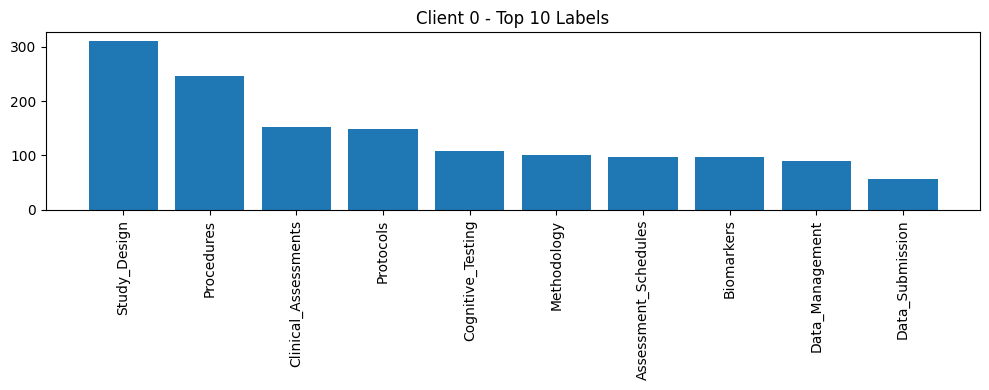

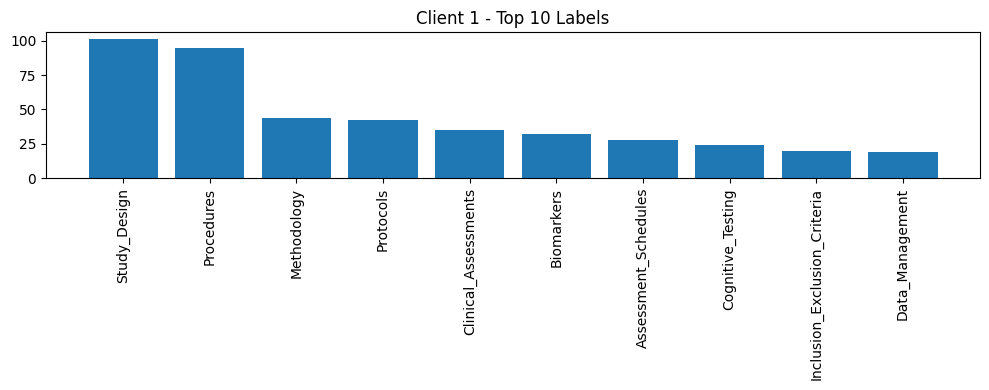

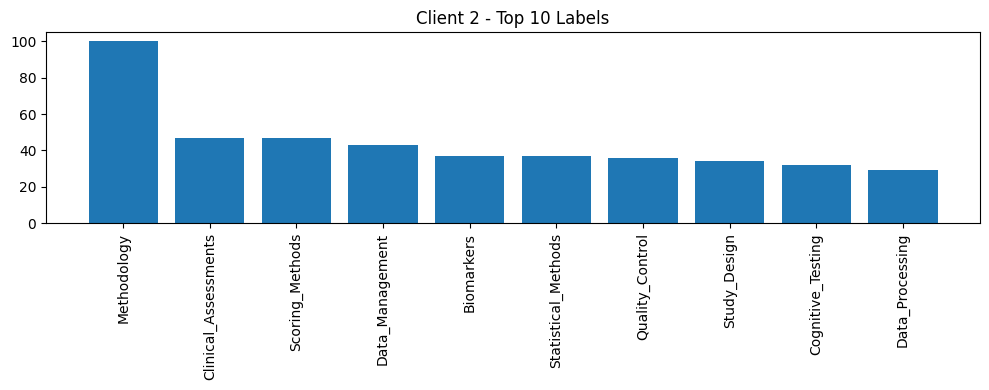

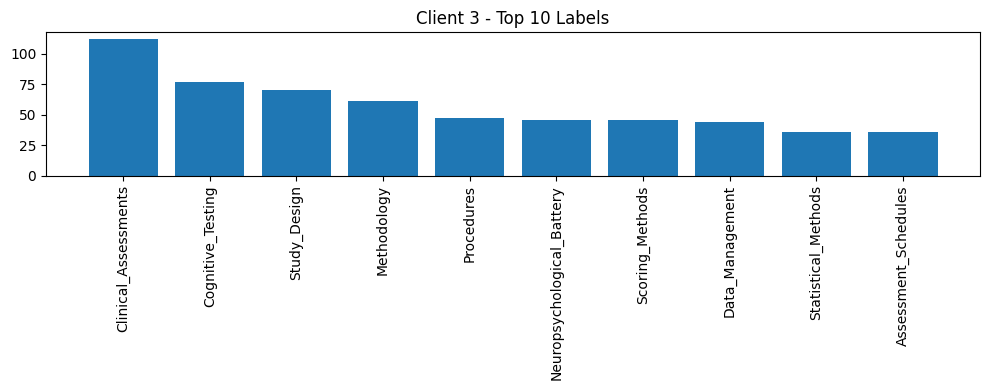

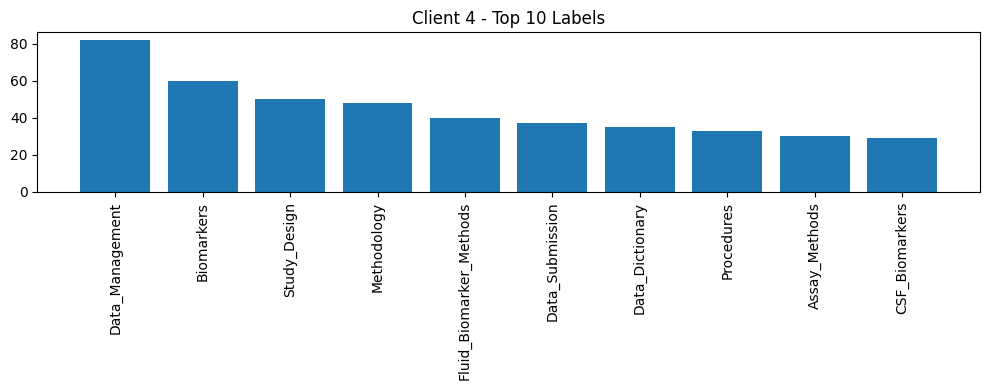

In [40]:
# ============================================================
# CELL 34 : Visualize Client Label Distribution
# ============================================================

import matplotlib.pyplot as plt

for client_id in range(NUM_CLIENTS):

    df = (
        pd.DataFrame(
            client_distribution[client_id].items(),
            columns=["Label", "Count"]
        )
        .sort_values("Count", ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10,4))
    plt.bar(df["Label"], df["Count"])
    plt.xticks(rotation=90)
    plt.title(f"Client {client_id} - Top 10 Labels")
    plt.tight_layout()
    plt.show()

In [41]:
# ============================================================
# CELL 35 : Create Client DataLoaders
# ============================================================

from torch.utils.data import Subset, DataLoader

BATCH_SIZE = 8

client_datasets = {}
client_loaders = {}

for client_id in range(NUM_CLIENTS):

    subset = Subset(dataset, client_indices[client_id])

    loader = DataLoader(
        subset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    client_datasets[client_id] = subset
    client_loaders[client_id] = loader

print("Client DataLoaders Created\n")

for client_id in range(NUM_CLIENTS):
    print(
        f"Client {client_id}: "
        f"{len(client_datasets[client_id])} samples | "
        f"{len(client_loaders[client_id])} batches"
    )

Client DataLoaders Created

Client 0: 311 samples | 39 batches
Client 1: 104 samples | 13 batches
Client 2: 104 samples | 13 batches
Client 3: 121 samples | 16 batches
Client 4: 105 samples | 14 batches


In [42]:
# ============================================================
# CELL 36 : Global Test Loader
# ============================================================

from torch.utils.data import random_split

TEST_RATIO = 0.20

test_size = int(TEST_RATIO * len(dataset))
train_size = len(dataset) - test_size

global_train_dataset, global_test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

test_loader = DataLoader(
    global_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Global Test Samples:", len(global_test_dataset))

Global Test Samples: 149


In [43]:
import os

for root, dirs, files in os.walk("/kaggle/working/PPFLCTRURH/NLP pipline"):
    for file in files:
        if file.endswith(".py"):
            print(os.path.join(root, file))

/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/setup.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/__init__.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/configs/__init__.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/configs/config.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/__init__.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/label_encoder.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/data_plugin.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/preprocess.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/hierarchy.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/dataset.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/api/interface.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handof

In [44]:
import os

for root, dirs, files in os.walk("/kaggle/working/PPFLCTRURH/NLP pipline"):
    for file in files:
        if file.endswith(".py"):
            path = os.path.join(root, file)
            with open(path, "r", encoding="utf-8") as f:
                text = f.read()
                if "class ClinicalHMLTCModel" in text:
                    print(path)

/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/models/model.py


In [45]:
import sys

for p in sys.path:
    print(p)

/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff
/kaggle/working
/kaggle/lib/kagglegym
/kaggle/lib
/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/usr/local/lib/python3.12/dist-packages
/usr/lib/python3/dist-packages
/usr/local/lib/python3.12/dist-packages/IPython/extensions
/root/.ipython


In [46]:
import os

ROOT = "/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff"

print(os.path.exists(ROOT))
print(os.listdir(ROOT))

True
['nlp_pipeline', 'setup.py', 'README.md']


In [47]:
import sys

ROOT = "/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff"

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print(sys.path[0])

/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff


In [48]:
from nlp_pipeline.models.model import ClinicalHMLTCModel

print("Import successful")

Import successful


In [49]:
import inspect
from nlp_pipeline.models.model import ClinicalHMLTCModel

print(inspect.signature(ClinicalHMLTCModel))

(model_name: 'str' = 'microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext', num_labels: 'int' = 50, dropout_rate: 'float' = 0.3, use_label_attention: 'bool' = False) -> 'None'


In [50]:
import inspect
from nlp_pipeline.models.model import ClinicalHMLTCModel

print(inspect.getsource(ClinicalHMLTCModel.__init__))

    def __init__(
        self,
        model_name: str = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext",
        num_labels: int = 50,
        dropout_rate: float = 0.3,
        use_label_attention: bool = False,
    ) -> None:
        super().__init__()
        self.num_labels = num_labels
        self.use_label_attention = use_label_attention

        # ── Encoder ─────────────────────────────────────────────────
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size: int = self.encoder.config.hidden_size

        if use_label_attention:
            # ── V3 path: Label Attention + CLS fusion ───────────────
            self.label_attention = LabelAttentionHead(hidden_size, num_labels)
            self.dropout = nn.Dropout(dropout_rate)
            self.fusion = nn.Sequential(
                nn.Linear(hidden_size * 2, hidden_size),
                nn.GELU(),
                nn.Dropout(dropout_rate),
                nn.Linear(hidden_size, 1)

In [51]:
# ============================================================
# CELL 37 : Initialize Clinical HMLTC Model
# ============================================================

import torch
from nlp_pipeline.models.model import ClinicalHMLTCModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ClinicalHMLTCModel(
    num_labels=label_encoder_obj.num_labels,
    use_label_attention=False
)

model = model.to(device)

print("Device:", device)
print("Number of labels:", label_encoder_obj.num_labels)
print("Model initialized successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda
Number of labels: 32
Model initialized successfully.


In [52]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
2
Tesla T4


In [53]:
import os

for root, dirs, files in os.walk("/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff"):
    if "train.py" in files:
        print(os.path.join(root, "train.py"))

In [54]:
import os

ROOT = "/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff"

for root, dirs, files in os.walk(ROOT):
    for file in files:
        if file.endswith(".py"):
            print(os.path.join(root, file))

/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/setup.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/__init__.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/configs/__init__.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/configs/config.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/__init__.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/label_encoder.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/data_plugin.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/preprocess.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/hierarchy.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/data/dataset.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/api/interface.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handof

In [55]:
import os

ROOT = "/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff"

for root, dirs, files in os.walk(ROOT):
    for file in files:
        if file.endswith(".py"):
            path = os.path.join(root, file)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    text = f.read()
                    if "train_one_epoch" in text:
                        print(path)
            except:
                pass

/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/api/interface.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/training/__init__.py
/kaggle/working/PPFLCTRURH/NLP pipline/federated_handoff/nlp_pipeline/training/trainer.py


In [56]:
import inspect

from nlp_pipeline.training.trainer import train_one_epoch

print(inspect.signature(train_one_epoch))

(model: 'nn.Module', dataloader: 'DataLoader', optimizer: 'torch.optim.Optimizer', loss_fn: 'nn.Module', device: 'str | torch.device', *, scheduler: 'Optional[Any]' = None, grad_accum_steps: 'int' = 1, max_grad_norm: 'float' = 1.0, epoch_idx: 'int' = 0, total_epochs: 'int' = 1, silent: 'bool' = False) -> 'Dict[str, float]'


In [57]:
import inspect
import nlp_pipeline.models.loss as loss_module

print(inspect.getsource(loss_module))

"""
Configurable loss functions for hierarchical multi-label classification.

Extracted and operationalised from the scaffolded ``HierarchicalLoss``
in Phase 2 notebook Section 5.1.  Now split into composable, standalone
modules that can be used individually or combined:

  - ``FocalLoss``                — class-imbalance-aware BCE
  - ``HierarchicalConsistencyLoss`` — parent-child violation penalty
  - ``CombinedHMLTCLoss``       — composes any combination of the above

Usage
-----
Select via ``PipelineConfig.loss_type``:

    ============  ======================================
    loss_type     Result
    ============  ======================================
    ``"bce"``     Standard ``BCEWithLogitsLoss``
    ``"focal"``   ``FocalLoss``
    ``"hierarchical"``  ``BCEWithLogitsLoss`` + ``HierarchicalConsistencyLoss``
    ``"combined"``      ``FocalLoss`` + ``HierarchicalConsistencyLoss``
    ============  ======================================
"""

from __future__ import annotations



In [58]:
from nlp_pipeline.configs.config import PipelineConfig

cfg = PipelineConfig()

print(cfg)

PipelineConfig(data_dir=PosixPath('data_generation'), output_dir=PosixPath('model_outputs'), chunk_size=512, chunk_overlap=64, min_chunk_size=50, coding_system='auto', hierarchy_depth=-1, hierarchy_file=None, model_name='microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext', max_seq_length=512, dropout_rate=0.3, use_label_attention=False, loss_type='combined', focal_gamma=2.0, focal_alpha=None, hierarchy_penalty_weight=0.5, label_smoothing=0.1, batch_size=8, learning_rate=2e-05, num_epochs=5, warmup_ratio=0.1, weight_decay=0.01, grad_accum_steps=2, max_grad_norm=1.0, classification_threshold=0.5, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, device='cuda', num_workers=0, pin_memory=True, mixed_precision=False, log_every_n_steps=10)


In [59]:
print("Hierarchy attributes:")
print(dir(hierarchy))

print("\nLabel Encoder attributes:")
print(dir(label_encoder_obj))

Hierarchy attributes:
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'all_labels', 'child_labels', 'child_to_parent', 'coding_system', 'depth', 'ensure_parent_consistency', 'from_codes', 'from_json', 'from_mapping', 'get_children', 'get_parent', 'num_children', 'num_labels', 'num_parents', 'parent_labels', 'parent_to_children', 'summary', 'to_json']

Label Encoder attributes:
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__siz

In [65]:
from nlp_pipeline.models.loss import build_loss
from nlp_pipeline.configs.config import PipelineConfig

cfg = PipelineConfig()

loss_fn = build_loss(
    loss_type=cfg.loss_type,
    focal_gamma=cfg.focal_gamma,
    focal_alpha=cfg.focal_alpha,
    label_smoothing=cfg.label_smoothing,
    hierarchy_penalty_weight=cfg.hierarchy_penalty_weight,
    child_to_parent=hierarchy.child_to_parent,
    label_to_idx=label_encoder_obj.label_to_idx,
)

print(loss_fn)

CombinedHMLTCLoss(
  (primary_loss): FocalLoss()
  (hierarchy_loss): HierarchicalConsistencyLoss()
)


In [66]:
import torch
from torch.optim import AdamW

def build_optimizer(model):
    return AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

print("Optimizer Builder Ready")

Optimizer Builder Ready


In [67]:
import copy
import torch

def get_model_weights(model):
    return copy.deepcopy(model.state_dict())


def set_model_weights(model, weights):
    model.load_state_dict(copy.deepcopy(weights))


print("Weight utilities ready.")

Weight utilities ready.


In [68]:
import copy
import torch

def fedavg(client_weights):

    global_weights = copy.deepcopy(client_weights[0])

    for key in global_weights.keys():

        for i in range(1, len(client_weights)):
            global_weights[key] += client_weights[i][key]

        global_weights[key] = global_weights[key] / len(client_weights)

    return global_weights

print("FedAvg Ready")

FedAvg Ready


In [69]:
import copy

from nlp_pipeline.training.trainer import train_one_epoch


def train_client(global_model, trainloader):

    client_model = copy.deepcopy(global_model)

    optimizer = build_optimizer(client_model)

    metrics = train_one_epoch(
        model=client_model,
        dataloader=trainloader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        scheduler=None,
        grad_accum_steps=cfg.grad_accum_steps,
        max_grad_norm=cfg.max_grad_norm,
        epoch_idx=0,
        total_epochs=1,
        silent=True,
    )

    return client_model, metrics

In [70]:
# Show all variables containing "client" or "loader"

for var in list(globals().keys()):
    if "client" in var.lower() or "loader" in var.lower():
        print(var)

__loader__
DataLoader
NUM_CLIENTS
client_sample_counts
client_indices
client_primary_labels
client_id
smallest_client
client_distribution
client_datasets
client_loaders
loader
test_loader
train_client


In [73]:
import copy
import torch

# ======================================
# Federated Training (FedAvg)
# ======================================

NUM_ROUNDS = 10

global_model = copy.deepcopy(model)

round_losses = []

print("=" * 60)
print("Starting Federated Training (FedAvg)")
print("=" * 60)

for rnd in range(NUM_ROUNDS):

    print(f"\nCommunication Round {rnd + 1}/{NUM_ROUNDS}")

    client_weights = []
    client_losses = []

    # ---------------------------
    # Local Training
    # ---------------------------
    for client_id, trainloader in client_loaders.items():

        print(f"Training Client {client_id}")

        client_model, metrics = train_client(
            global_model,
            trainloader,
        )

        client_weights.append(
            get_model_weights(client_model)
        )

        if isinstance(metrics, dict):

            if "loss" in metrics:
                client_losses.append(metrics["loss"])

            elif "train_loss" in metrics:
                client_losses.append(metrics["train_loss"])

    # ---------------------------
    # FedAvg Aggregation
    # ---------------------------
    global_weights = fedavg(client_weights)

    set_model_weights(
        global_model,
        global_weights,
    )

    avg_loss = (
        sum(client_losses) / len(client_losses)
        if len(client_losses) > 0
        else 0.0
    )

    round_losses.append(avg_loss)

    print(f"Average Round Loss: {avg_loss:.4f}")

print("\nFederated Training Completed Successfully!")

Starting Federated Training (FedAvg)

Communication Round 1/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss: 0.1620

Communication Round 2/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss: 0.1324

Communication Round 3/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss: 0.1188

Communication Round 4/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss: 0.1137

Communication Round 5/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss: 0.1106

Communication Round 6/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss: 0.1092

Communication Round 7/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Trainin

In [74]:
from nlp_pipeline.training import trainer

print([name for name in dir(trainer) if "eval" in name.lower() or "test" in name.lower()])

[]


In [75]:
# Take one batch from the test loader
batch = next(iter(test_loader))

batch = {k: v.to(device) for k, v in batch.items()}

global_model.eval()

with torch.no_grad():
    outputs = global_model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
    )

print(type(outputs))

if isinstance(outputs, dict):
    print("\nKeys:")
    print(outputs.keys())

elif isinstance(outputs, tuple):
    print("\nTuple length:", len(outputs))
    for i, out in enumerate(outputs):
        if hasattr(out, "shape"):
            print(f"Output {i}: {out.shape}")

elif hasattr(outputs, "shape"):
    print(outputs.shape)

<class 'torch.Tensor'>
torch.Size([8, 32])


In [78]:
import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
)


def evaluate_global_model(model, dataloader, threshold=0.5):

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            probs = torch.sigmoid(logits)

            preds = (probs >= threshold).int()

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels, axis=0)
    y_pred = np.concatenate(all_preds, axis=0)

    # ----------------------------
    # Metrics
    # ----------------------------

    subset_acc = accuracy_score(y_true, y_pred)

    hamming = hamming_loss(y_true, y_pred)

    micro_precision = precision_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0,
    )

    micro_recall = recall_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0,
    )

    micro_f1 = f1_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0,
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    print("=" * 60)
    print("Federated Global Model Evaluation")
    print("=" * 60)

    print(f"Subset Accuracy : {subset_acc:.4f}")
    print(f"Hamming Loss    : {hamming:.4f}")

    print("-" * 60)

    print(f"Micro Precision : {micro_precision:.4f}")
    print(f"Micro Recall    : {micro_recall:.4f}")
    print(f"Micro F1        : {micro_f1:.4f}")

    print("-" * 60)

    print(f"Macro Precision : {macro_precision:.4f}")
    print(f"Macro Recall    : {macro_recall:.4f}")
    print(f"Macro F1        : {macro_f1:.4f}")

    return {
        "subset_accuracy": subset_acc,
        "hamming_loss": hamming,
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": micro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
    }


fedavg_results = evaluate_global_model(
    global_model,
    test_loader,
)

Federated Global Model Evaluation
Subset Accuracy : 0.0067
Hamming Loss    : 0.1424
------------------------------------------------------------
Micro Precision : 0.8162
Micro Recall    : 0.3853
Micro F1        : 0.5235
------------------------------------------------------------
Macro Precision : 0.2455
Macro Recall    : 0.1518
Macro F1        : 0.1710


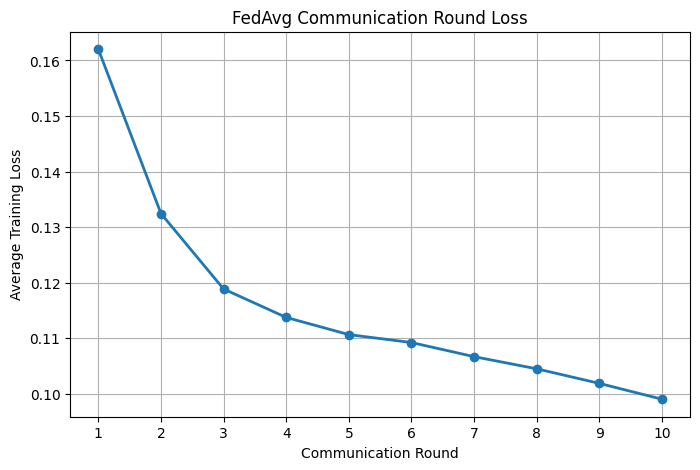

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(round_losses)+1),
    round_losses,
    linewidth=2,
    marker="o",
)

plt.title("FedAvg Communication Round Loss")

plt.xlabel("Communication Round")

plt.ylabel("Average Training Loss")

plt.xticks(range(1, len(round_losses)+1))

plt.grid(True)

plt.show()

In [80]:
import copy
import torch

MU = 0.01      # FedProx coefficient


def train_client_fedprox(global_model, trainloader):

    # Copy global model
    client_model = copy.deepcopy(global_model)

    optimizer = build_optimizer(client_model)

    client_model.train()

    total_loss = 0.0

    for batch in trainloader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = client_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        # Original task loss
        loss = loss_fn(logits, labels)

        # -------------------------
        # FedProx Regularization
        # -------------------------
        prox_loss = 0.0

        for param, global_param in zip(
                client_model.parameters(),
                global_model.parameters()
        ):
            prox_loss += torch.sum(
                (param - global_param.detach()) ** 2
            )

        loss = loss + (MU / 2.0) * prox_loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(trainloader)

    return client_model, avg_loss


print("FedProx client training ready.")

FedProx client training ready.


In [81]:
import copy

NUM_ROUNDS = 10

global_model_fedprox = copy.deepcopy(model)

fedprox_round_losses = []

print("=" * 60)
print("Starting Federated Training (FedProx)")
print("=" * 60)

for rnd in range(NUM_ROUNDS):

    print(f"\nCommunication Round {rnd+1}/{NUM_ROUNDS}")

    client_weights = []
    client_losses = []

    for client_id, trainloader in client_loaders.items():

        print(f"Training Client {client_id}")

        client_model, loss = train_client_fedprox(
            global_model_fedprox,
            trainloader,
        )

        client_weights.append(
            get_model_weights(client_model)
        )

        client_losses.append(loss)

    global_weights = fedavg(client_weights)

    set_model_weights(
        global_model_fedprox,
        global_weights,
    )

    avg_loss = sum(client_losses) / len(client_losses)

    fedprox_round_losses.append(avg_loss)

    print(f"Average Round Loss : {avg_loss:.4f}")

print("\nFedProx Training Completed.")

Starting Federated Training (FedProx)

Communication Round 1/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss : 0.1538

Communication Round 2/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss : 0.1217

Communication Round 3/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss : 0.1127

Communication Round 4/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss : 0.1096

Communication Round 5/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss : 0.1069

Communication Round 6/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Average Round Loss : 0.1044

Communication Round 7/10
Training Client 0
Training Client 1
Training Client 2
Training Client 3


In [82]:
fedprox_results = evaluate_global_model(
    global_model_fedprox,
    test_loader,
)

Federated Global Model Evaluation
Subset Accuracy : 0.0537
Hamming Loss    : 0.1256
------------------------------------------------------------
Micro Precision : 0.8462
Micro Recall    : 0.4659
Micro F1        : 0.6009
------------------------------------------------------------
Macro Precision : 0.3335
Macro Recall    : 0.2079
Macro F1        : 0.2341


In [83]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "Subset Accuracy",
        "Hamming Loss",
        "Micro Precision",
        "Micro Recall",
        "Micro F1",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],

    "FedAvg": [
        fedavg_results["subset_accuracy"],
        fedavg_results["hamming_loss"],
        fedavg_results["micro_precision"],
        fedavg_results["micro_recall"],
        fedavg_results["micro_f1"],
        fedavg_results["macro_precision"],
        fedavg_results["macro_recall"],
        fedavg_results["macro_f1"],
    ],

    "FedProx": [
        fedprox_results["subset_accuracy"],
        fedprox_results["hamming_loss"],
        fedprox_results["micro_precision"],
        fedprox_results["micro_recall"],
        fedprox_results["micro_f1"],
        fedprox_results["macro_precision"],
        fedprox_results["macro_recall"],
        fedprox_results["macro_f1"],
    ]
})

comparison

,Metric,FedAvg,FedProx
0,Subset Accuracy,0.006711,0.053691
1,Hamming Loss,0.142408,0.125629
2,Micro Precision,0.816193,0.846154
3,Micro Recall,0.385331,0.465909
4,Micro F1,0.523509,0.600933
5,Macro Precision,0.245471,0.333480
6,Macro Recall,0.151841,0.207937
7,Macro F1,0.170975,0.234084


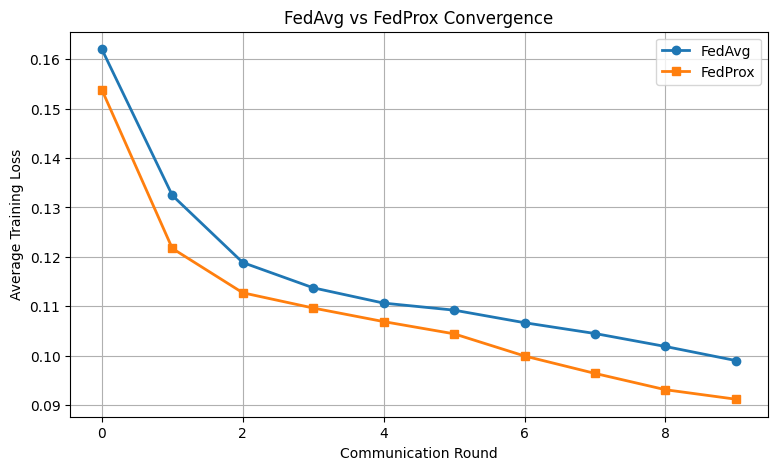

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(
    round_losses,
    marker='o',
    linewidth=2,
    label="FedAvg"
)

plt.plot(
    fedprox_round_losses,
    marker='s',
    linewidth=2,
    label="FedProx"
)

plt.xlabel("Communication Round")

plt.ylabel("Average Training Loss")

plt.title("FedAvg vs FedProx Convergence")

plt.legend()

plt.grid(True)

plt.show()

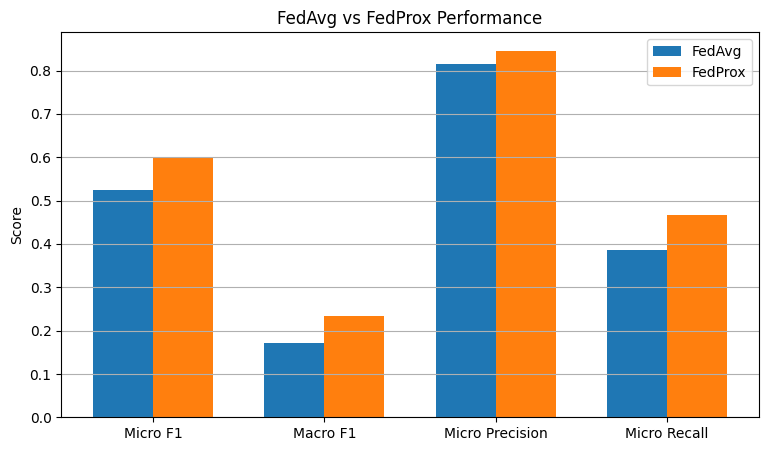

In [85]:
metrics = [
    "Micro F1",
    "Macro F1",
    "Micro Precision",
    "Micro Recall",
]

fedavg = [
    fedavg_results["micro_f1"],
    fedavg_results["macro_f1"],
    fedavg_results["micro_precision"],
    fedavg_results["micro_recall"],
]

fedprox = [
    fedprox_results["micro_f1"],
    fedprox_results["macro_f1"],
    fedprox_results["micro_precision"],
    fedprox_results["micro_recall"],
]

plt.figure(figsize=(9,5))

x = range(len(metrics))

width = 0.35

plt.bar(
    [i-width/2 for i in x],
    fedavg,
    width=width,
    label="FedAvg"
)

plt.bar(
    [i+width/2 for i in x],
    fedprox,
    width=width,
    label="FedProx"
)

plt.xticks(x, metrics)

plt.ylabel("Score")

plt.title("FedAvg vs FedProx Performance")

plt.legend()

plt.grid(axis="y")

plt.show()

In [95]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    global_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Train Samples:", len(global_train_dataset))
print("Test Samples :", len(global_test_dataset))

Train Samples: 596
Test Samples : 149


In [97]:
import copy

centralized_model = copy.deepcopy(model)

optimizer = build_optimizer(centralized_model)

NUM_EPOCHS = 10

centralized_losses = []

print("="*60)
print("Centralized Training")
print("="*60)

for epoch in range(NUM_EPOCHS):

    metrics = train_one_epoch(
        model=centralized_model,
        dataloader=train_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        silent=True,
    )

    centralized_losses.append(metrics["train_loss"])

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} "
        f"Loss = {metrics['train_loss']:.4f}"
    )

Centralized Training
Epoch 1/10 Loss = 0.1255
Epoch 2/10 Loss = 0.1026
Epoch 3/10 Loss = 0.0865
Epoch 4/10 Loss = 0.0759
Epoch 5/10 Loss = 0.0686
Epoch 6/10 Loss = 0.0630
Epoch 7/10 Loss = 0.0570
Epoch 8/10 Loss = 0.0531
Epoch 9/10 Loss = 0.0485
Epoch 10/10 Loss = 0.0450


In [98]:
centralized_results = evaluate_global_model(
    centralized_model,
    test_loader,
)

print("\nCentralized Results\n")

for k, v in centralized_results.items():
    print(f"{k:20s}: {v:.4f}")

Federated Global Model Evaluation
Subset Accuracy : 0.1007
Hamming Loss    : 0.0952
------------------------------------------------------------
Micro Precision : 0.8111
Micro Recall    : 0.6921
Micro F1        : 0.7469
------------------------------------------------------------
Macro Precision : 0.6824
Macro Recall    : 0.5238
Macro F1        : 0.5662

Centralized Results

subset_accuracy     : 0.1007
hamming_loss        : 0.0952
micro_precision     : 0.8111
micro_recall        : 0.6921
micro_f1            : 0.7469
macro_precision     : 0.6824
macro_recall        : 0.5238
macro_f1            : 0.5662


In [99]:
import copy

local_models = []
local_results = []

print("="*60)
print("Local (Siloed) Training")
print("="*60)

for client_id, loader in client_loaders.items():

    print(f"\nClient {client_id}")

    local_model = copy.deepcopy(model)

    optimizer = build_optimizer(local_model)

    for epoch in range(3):

        train_one_epoch(
            model=local_model,
            dataloader=loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device,
            silent=True,
        )

    result = evaluate_global_model(
        local_model,
        test_loader,
    )

    local_models.append(local_model)
    local_results.append(result)

Local (Siloed) Training

Client 0
Federated Global Model Evaluation
Subset Accuracy : 0.0336
Hamming Loss    : 0.1640
------------------------------------------------------------
Micro Precision : 0.7085
Micro Recall    : 0.3264
Micro F1        : 0.4470
------------------------------------------------------------
Macro Precision : 0.1679
Macro Recall    : 0.1197
Macro F1        : 0.1173

Client 1
Federated Global Model Evaluation
Subset Accuracy : 0.0000
Hamming Loss    : 0.1812
------------------------------------------------------------
Micro Precision : 0.6398
Micro Recall    : 0.2459
Micro F1        : 0.3552
------------------------------------------------------------
Macro Precision : 0.0563
Macro Recall    : 0.0765
Macro F1        : 0.0646

Client 2
Federated Global Model Evaluation
Subset Accuracy : 0.0000
Hamming Loss    : 0.2016
------------------------------------------------------------
Micro Precision : 0.5178
Micro Recall    : 0.1054
Micro F1        : 0.1751
--------------

In [100]:
import numpy as np

local_avg = {}

for key in local_results[0]:

    local_avg[key] = np.mean(
        [r[key] for r in local_results]
    )

print("Average Local Results\n")

for k, v in local_avg.items():
    print(f"{k:20s}: {v:.4f}")

Average Local Results

subset_accuracy     : 0.0067
hamming_loss        : 0.1926
micro_precision     : 0.5571
micro_recall        : 0.2215
micro_f1            : 0.3114
macro_precision     : 0.0785
macro_recall        : 0.0880
macro_f1            : 0.0720


In [101]:
import pandas as pd

comparison = pd.DataFrame({

    "Metric":[
        "Subset Accuracy",
        "Hamming Loss",
        "Micro Precision",
        "Micro Recall",
        "Micro F1",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
    ],

    "Centralized":[
        centralized_results["subset_accuracy"],
        centralized_results["hamming_loss"],
        centralized_results["micro_precision"],
        centralized_results["micro_recall"],
        centralized_results["micro_f1"],
        centralized_results["macro_precision"],
        centralized_results["macro_recall"],
        centralized_results["macro_f1"],
    ],

    "Local":[
        local_avg["subset_accuracy"],
        local_avg["hamming_loss"],
        local_avg["micro_precision"],
        local_avg["micro_recall"],
        local_avg["micro_f1"],
        local_avg["macro_precision"],
        local_avg["macro_recall"],
        local_avg["macro_f1"],
    ],

    "FedAvg":[
        fedavg_results["subset_accuracy"],
        fedavg_results["hamming_loss"],
        fedavg_results["micro_precision"],
        fedavg_results["micro_recall"],
        fedavg_results["micro_f1"],
        fedavg_results["macro_precision"],
        fedavg_results["macro_recall"],
        fedavg_results["macro_f1"],
    ],

    "FedProx":[
        fedprox_results["subset_accuracy"],
        fedprox_results["hamming_loss"],
        fedprox_results["micro_precision"],
        fedprox_results["micro_recall"],
        fedprox_results["micro_f1"],
        fedprox_results["macro_precision"],
        fedprox_results["macro_recall"],
        fedprox_results["macro_f1"],
    ]

})

comparison

,Metric,Centralized,Local,FedAvg,FedProx
0,Subset Accuracy,0.100671,0.006711,0.006711,0.053691
1,Hamming Loss,0.095218,0.192617,0.142408,0.125629
2,Micro Precision,0.811138,0.557116,0.816193,0.846154
3,Micro Recall,0.692149,0.221488,0.385331,0.465909
4,Micro F1,0.746934,0.311368,0.523509,0.600933
5,Macro Precision,0.682430,0.078493,0.245471,0.333480
6,Macro Recall,0.523835,0.088023,0.151841,0.207937
7,Macro F1,0.566165,0.071988,0.170975,0.234084


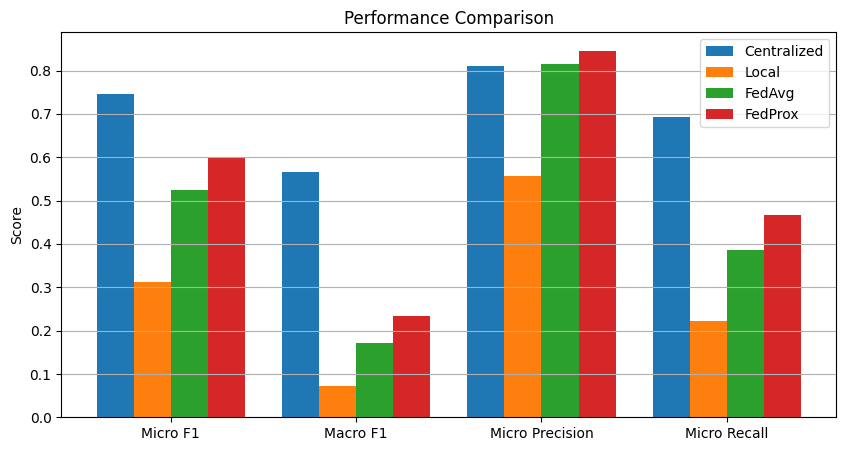

In [102]:
import matplotlib.pyplot as plt

metrics = [
    "Micro F1",
    "Macro F1",
    "Micro Precision",
    "Micro Recall"
]

centralized = [
    centralized_results["micro_f1"],
    centralized_results["macro_f1"],
    centralized_results["micro_precision"],
    centralized_results["micro_recall"],
]

local = [
    local_avg["micro_f1"],
    local_avg["macro_f1"],
    local_avg["micro_precision"],
    local_avg["micro_recall"],
]

fedavg = [
    fedavg_results["micro_f1"],
    fedavg_results["macro_f1"],
    fedavg_results["micro_precision"],
    fedavg_results["micro_recall"],
]

fedprox = [
    fedprox_results["micro_f1"],
    fedprox_results["macro_f1"],
    fedprox_results["micro_precision"],
    fedprox_results["micro_recall"],
]

x = range(len(metrics))
w = 0.2

plt.figure(figsize=(10,5))

plt.bar([i-1.5*w for i in x], centralized, width=w, label="Centralized")
plt.bar([i-0.5*w for i in x], local, width=w, label="Local")
plt.bar([i+0.5*w for i in x], fedavg, width=w, label="FedAvg")
plt.bar([i+1.5*w for i in x], fedprox, width=w, label="FedProx")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison")
plt.legend()
plt.grid(axis="y")

plt.show()

In [103]:
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import copy
import numpy as np

# -------------------------
# Differential Privacy Config
# -------------------------

MAX_GRAD_NORM = 1.0
NOISE_MULTIPLIER = 1.1
DELTA = 1e-5

DP_LOCAL_EPOCHS = 2
DP_NUM_ROUNDS = 10

print("=" * 60)
print("Differential Privacy Configuration")
print("=" * 60)

print(f"Noise Multiplier : {NOISE_MULTIPLIER}")
print(f"Max Grad Norm    : {MAX_GRAD_NORM}")
print(f"Delta            : {DELTA}")

Differential Privacy Configuration
Noise Multiplier : 1.1
Max Grad Norm    : 1.0
Delta            : 1e-05


In [104]:
validation_errors = ModuleValidator.validate(model)

if len(validation_errors) == 0:
    print("✓ Model is compatible with Opacus.")
else:
    print("Model requires fixes:")
    for err in validation_errors:
        print(err)

✓ Model is compatible with Opacus.


In [105]:
def train_client_dp(
    model,
    train_loader,
    device,
    epochs=DP_LOCAL_EPOCHS,
):

    model = copy.deepcopy(model)

    optimizer = build_optimizer(model)

    privacy_engine = PrivacyEngine()

    model, optimizer, train_loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        noise_multiplier=NOISE_MULTIPLIER,
        max_grad_norm=MAX_GRAD_NORM,
    )

    model.train()

    epoch_losses = []

    for epoch in range(epochs):

        running_loss = 0.0

        for batch in train_loader:

            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            logits = outputs["logits"]

            loss = loss_fn(logits, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        epoch_losses.append(avg_loss)

        epsilon = privacy_engine.get_epsilon(DELTA)

        print(
            f"Epoch {epoch+1}/{epochs}"
            f" | Loss = {avg_loss:.4f}"
            f" | ε = {epsilon:.2f}"
        )

    epsilon = privacy_engine.get_epsilon(DELTA)

    return (
        model,
        epoch_losses,
        epsilon,
    )